# Pipelines y Prevención de Data Leakage

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/09_pipelines_y_prevencion_leakage.ipynb)

## Objetivos


- Comprender el concepto de **Data Leakage** (Fuga de Datos) y cómo arruina la validez de los modelos en producción.
- Construir un flujo de trabajo profesional utilizando `Pipeline` y `ColumnTransformer` de Scikit-Learn.
- Integrar la imputación de valores nulos, la codificación de variables categóricas, el escalado numérico y el modelo predictivo en un único objeto inmutable.



## Prerrequisitos


- Entendimiento de la Validación Cruzada (K-Fold CV).
- Haber completado: [Optimización de Hiperparámetros y Validación Cruzada](07_optimizacion_hiperparametros_y_cv.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



Hasta ahora, en nuestros notebooks anteriores, hemos hecho "trampa" pedagógica. Para enfocarnos en los algoritmos, eliminamos las filas con valores nulos (`dropna()`) y convertimos las variables categóricas a numéricas (`pd.get_dummies()`) **antes** de dividir los datos en Train y Test.

En el mundo real, hacer esto es un pecado capital de ingeniería conocido como **Data Leakage** (Fuga de Datos).



### ¿Qué es el Data Leakage?



Ocurre cuando información del conjunto de prueba (*Test Set*) o de validación se filtra hacia el conjunto de entrenamiento (*Train Set*).

**Ejemplo 1: Imputación de Nulos**
Supongamos que se tienen 100 pacientes y a 10 les falta el valor del IMC. Se decide rellenar esos huecos con el promedio del IMC de los 100 pacientes. Luego, se dividen los datos 80/20.
¡Error! El promedio que se usó para rellenar los datos de entrenamiento contiene información de los 20 pacientes de prueba. El modelo está "espiando" el futuro.

**Ejemplo 2: Escalado (StandardScaler)**
Si se escala todo el dataset antes de hacer Validación Cruzada (CV), la media y la desviación estándar utilizadas para escalar contienen información de todos los *folds*. Cuando el algoritmo separe el *fold* de validación, ese *fold* ya estará contaminado. El CV mentirá, dándo un *Accuracy* artificialmente alto.


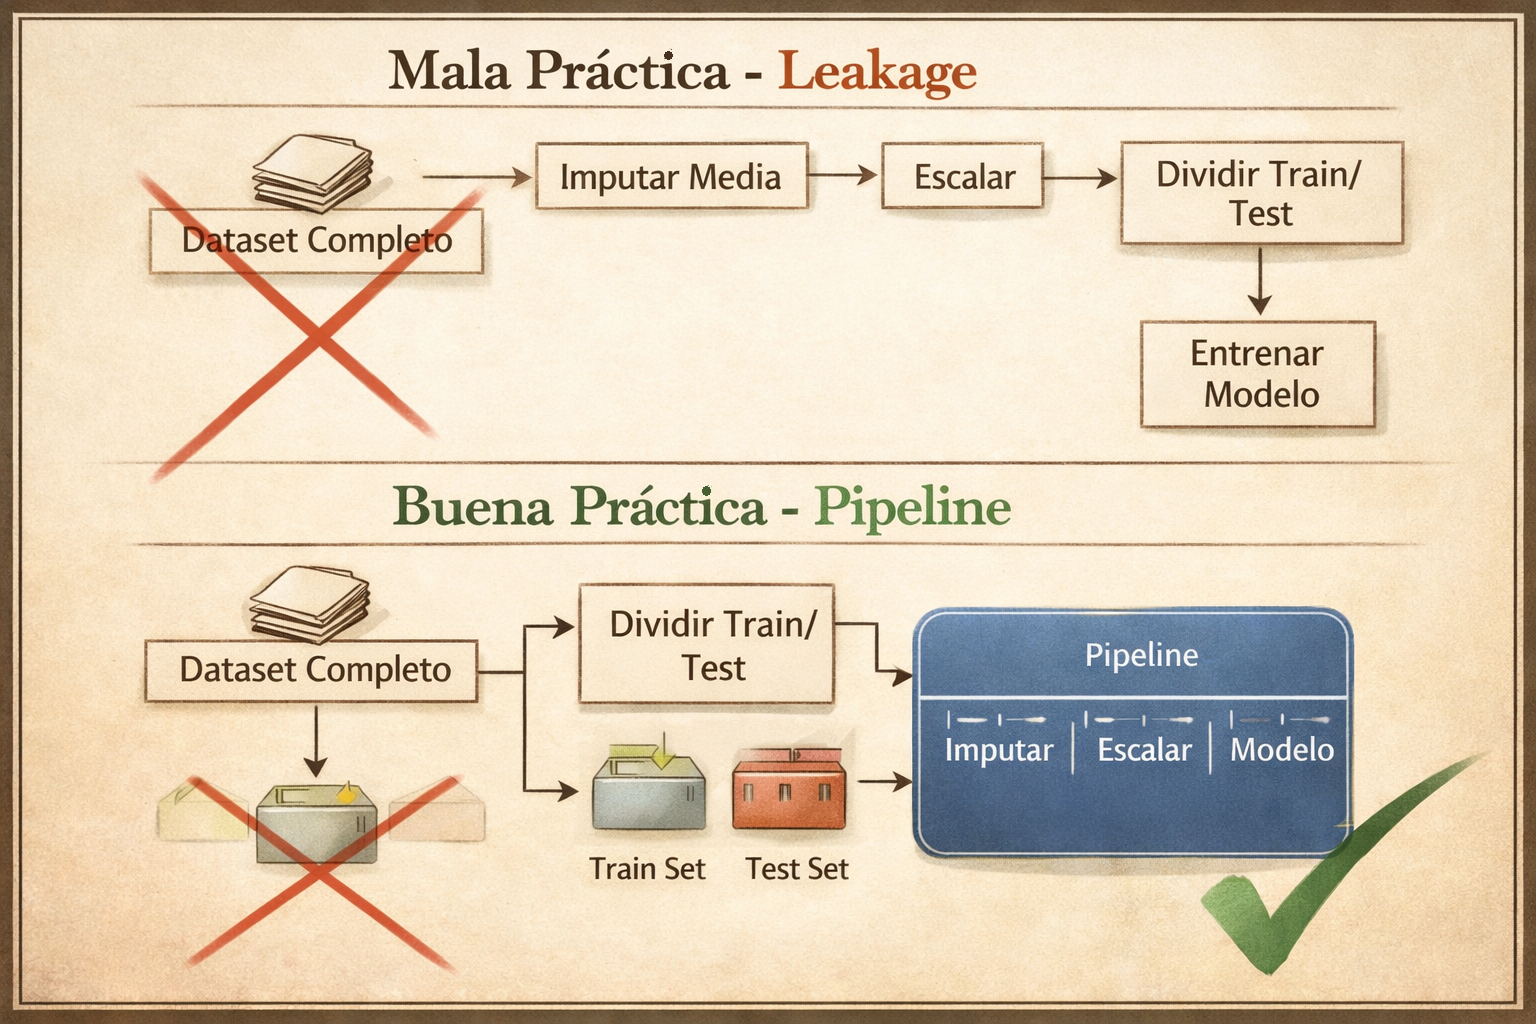

### La Solución: El Pipeline



Un `Pipeline` es un objeto de Scikit-Learn que encadena múltiples pasos de procesamiento de datos y un estimador final (el modelo).

La magia del Pipeline es que, durante la Validación Cruzada, **ejecuta todos los pasos de preprocesamiento de forma independiente para cada fold de entrenamiento**, garantizando que el fold de validación permanezca matemáticamente puro.



## Desarrollo e Implementación



Vamos a utilizar el **Stroke Prediction Dataset (ACV)** completo, con todos sus valores nulos y variables categóricas en texto.



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Carga de datos crudos
dataset_path = "datasets/acv/datos_acv.csv"
df = load_dataset(dataset_path)

# Eliminamos el ID (no predictivo)
df = df.drop(columns=['id'])

# Separamos Features (X) y Target (y)
X = df.drop(columns=['apoplejia'])
y = df['apoplejia']

# 2. División Train/Test INMEDIATA (Antes de tocar cualquier dato)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Valores nulos en Train (IMC): {X_train['imc'].isnull().sum()}")
print(f"Valores nulos en Test (IMC): {X_test['imc'].isnull().sum()}")

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/acv/datos_acv.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 5110 filas y 12 columnas.
Valores nulos en Train (IMC): 170
Valores nulos en Test (IMC): 31


### Construyendo el ColumnTransformer



Nuestros datos son heterogéneos. Tenemos columnas numéricas (Edad, Glucosa, IMC) y columnas categóricas (Género, Tipo de Trabajo, Estado Fumador). No podemos aplicar el mismo preprocesamiento a todas.

Usaremos un `ColumnTransformer` para crear "rutas" separadas para cada tipo de dato.



In [5]:
# Identificamos las columnas por tipo
columnas_numericas = ['edad', 'nivel_glucosa', 'imc']
columnas_categoricas = ['genero', 'hipertension', 'enfermedad_corazon', 'casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia', 'estado_fumador']

# Ruta 1: Preprocesamiento para variables numéricas
# Paso A: Imputar nulos con la mediana (robusto a outliers)
# Paso B: Escalar los datos (StandardScaler)
pipeline_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

# Ruta 2: Preprocesamiento para variables categóricas
# Paso A: Imputar nulos con la categoría más frecuente (por si acaso)
# Paso B: Convertir texto a números (OneHotEncoder, ignorando categorías nuevas en Test)
pipeline_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Unimos ambas rutas en un ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, columnas_numericas),
        ('cat', pipeline_categorico, columnas_categoricas)
    ])

### Ensamblando el Pipeline Final



Ahora, conectamos nuestro `preprocesador` con el modelo predictivo (un Random Forest) para crear el objeto final.



In [14]:
# Creamos el Pipeline completo
modelo_pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42))
])

# Entrenamos TODO el pipeline con una sola línea de código
# Aquí, el pipeline calcula la mediana del IMC, la media de la glucosa,
# aprende las categorías de texto, transforma los datos y entrena el Random Forest.
modelo_pipeline.fit(X_train, y_train)

print("¡Pipeline entrenado exitosamente!")

¡Pipeline entrenado exitosamente!


### Evaluando el Sistema en Producción



Cuando llega un paciente nuevo (o nuestro Test Set), no necesitamos imputar ni escalar nada manualmente. Simplemente le pasamos los datos crudos al Pipeline. Él recordará la mediana del IMC del Train Set y la aplicará al paciente nuevo.



In [15]:
# Predecimos sobre el Test Set crudo (con nulos y texto)
y_pred = modelo_pipeline.predict(X_test)

print("Reporte de Clasificación (Test Set):")
print(classification_report(y_test, y_pred))

Reporte de Clasificación (Test Set):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



**NOTA**: ¿Qué pasó con los resultados? ¿No sería esto un modelo inservible para el contexto del problema?

Exacto, pero los hiperparámetros siguen siendo muy importantes. Probar de disminuir (bastante) la cantidad de estimadores (árboles) del Random Forest y ejecutar el pipeline nuevamente.

## Resultados y Discusión



El código anterior es la forma en que se escribe Machine Learning en la industria.

**Ventajas de Ingeniería del Pipeline:**
1. **Seguridad (Cero Leakage):** Si pasamos este `modelo_pipeline` a un `GridSearchCV` (como vimos en el notebook [Optimización de Hiperparámetros y Validación Cruzada](07_optimizacion_hiperparametros_y_cv.ipynb)), Scikit-Learn es lo suficientemente inteligente como para re-calcular la mediana del IMC y el escalado en cada uno de los 5 *folds* de entrenamiento, manteniendo el *fold* de validación inmaculado.
2. **Reproducibilidad:** Todo el flujo de trabajo está encapsulado en un solo objeto. Se puede guardar este objeto en un archivo `.pkl` (Pickle) o `.joblib`, enviarlo al equipo de Backend, y ellos solo tendrán que hacer `modelo_cargado.predict(datos_del_usuario)`.
3. **Mantenibilidad:** Si mañana se decide cambiar el `StandardScaler` por un `MinMaxScaler`, solo se cambia una línea de código en la definición del Pipeline. No hay necesidad de reescribir docenas de celdas de Pandas.


### Visualizando el Pipeline



Scikit-Learn nos permite visualizar la arquitectura de nuestro sistema para documentarlo fácilmente.



In [16]:
from sklearn import set_config

# Configuramos sklearn para que muestre diagramas HTML
set_config(display="diagram")

# Mostramos el pipeline
modelo_pipeline

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalador',
                                                                   StandardScaler())]),
                                                  ['edad', 'nivel_glucosa',
                                                   'imc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('codificador',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['genero', 'hipertension',
                                                   'enfermedad_corazon',
                                                   'casado_alguna_vez',
                                                   'tipo_trabajo',
                                                   'tipo_residencia',
                                                   'estado_fumador'])])),
                ('clasificador',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=50, random_state=42))])

*(Si estás ejecutando esto en un entorno Jupyter/Colab, verás un diagrama interactivo del flujo de datos).*



## Conexiones y Próximos Pasos



Hemos construido un sistema robusto que ingiere datos crudos, los limpia, los transforma y emite una predicción. Sin embargo, nuestro modelo está utilizando todas las variables disponibles.

En un entorno IoT o médico, recolectar cada variable cuesta dinero (sensores, exámenes de laboratorio). ¿Qué pasaría si pudiéramos obtener el mismo rendimiento usando solo la mitad de las variables?

- ➡️ **Siguiente:** En el [Notebook 10: Selección de Variables y AutoML](10_seleccion_variables_y_automl.ipynb), cerraremos el capítulo aprendiendo a reducir la dimensionalidad de forma inteligente (Feature Selection) para optimizar costos de hardware y establecer *baselines* rápidos.
- 🔄 **Relacionado:** Si se quiere entender por qué elegimos un Random Forest para este problema de clases desbalanceadas, repasar el notebook [Ensamblado de Modelos](08_ensamblado_de_modelos.ipynb).



## Referencias


1. [Scikit-Learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
2. [Scikit-Learn: Common pitfalls and recommended practices (Data Leakage)](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

---


## Entorno de Ejecución


In [17]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
